In [1]:
import os
import pickle
import torch
import pandas as pd
import numpy as np
import optuna
from datetime import datetime
import glob
from utils import parse_combination, create_model_with_dynamic_dims, mets_cols
from data_import import DataPreprocessor, DataLoaderManager
from MetS_prediction_model import train_sklearn_ensemble
from resampling import create_resampled_dataset
from feature_engineering import apply_to_all_data
from train_eval_function import train_model_with_loss
from data_import import SingleDietImpactDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda
Device: cuda


In [2]:
data_path = '../data/total_again.xlsx'
data_processor = DataPreprocessor(data_path)

Device: cuda


In [3]:
train_df_global, val_df_global, test_df_global, _ = data_processor.process_all(
    normalize=True, selection_strategy='max_disease_change'
)
train_df_global, val_df_global, test_df_global, _ = apply_to_all_data(
    train_df_global, val_df_global, test_df_global
)

Initial data shape: (29098, 58)
Data shape after max disease change selection: (11238, 65)
Total unique patients: 11238
=== 피처 엔지니어링 시작 ===
✅ PCA 설명 분산비: 0.997
=== 피처 엔지니어링 완료 ===
상호작용 피처: 6개
PCA 피처: 10개
실제 change_dim: 6


### 1단계: 최고 방법 조합 찾기 -> best_combo

In [4]:
cache_file = '../result/best_combo/comprehensive_combo_cache.pkl'

try:
    with open(cache_file, 'rb') as f:
        cached_data = pickle.load(f)
    all_results = cached_data['all_results']
    best_combo = cached_data['best_combo']
    best_score = cached_data['best_score']
    sel_strategy, mod_method, resample_method, loss_method = best_combo
    print(f"캐시에서 불러온 최고 조합: {best_combo}, 점수: {best_score:.3f}")
except (FileNotFoundError, Exception):
    selection_strategies = ['max_disease_change', 'first_last']
    model_methods = ['base', 'ensemble']
    resampling_methods = ['none', 'smote']
    loss_methods = ['CrossEntropy', 'FocalLoss', 'WeightedCE_log']

    best_combo = None
    best_score = 0
    all_results = {}

    total_combinations = len(selection_strategies) * len(model_methods) * len(resampling_methods) * len(loss_methods)
    print(f"총 {total_combinations}개 조합 테스트 시작...")

    combination_count = 0
    for sel_strategy in selection_strategies:
        for mod_method in model_methods:
            for resample_method in resampling_methods:
                for loss_method in loss_methods:
                    combination_count += 1
                    combo_name = f"{sel_strategy}_{mod_method}_{resample_method}_{loss_method}"
                    temp_train, temp_val, temp_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
                    temp_train, temp_val, temp_test, actual_change_dim = apply_to_all_data(temp_train, temp_val, temp_test)
                    
                    temp_dataset = SingleDietImpactDataset(temp_train)
                    print(f"  피처 수: {len(temp_train.columns)}")
                    
                    if mod_method == 'ensemble':
                        disease = mets_cols[0]
                        result = train_sklearn_ensemble(temp_train, temp_val, temp_test, disease)
                        score = result['f1_score']
                    else:
                        model = create_model_with_dynamic_dims(temp_dataset, mets_cols).to(device)
                        
                        if resample_method == 'none':
                            train_loaders, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                                temp_train, temp_val, temp_test, batch_size=32)
                        else:
                            resampled_train = create_resampled_dataset(temp_train, resample_method)
                            train_loaders = {disease: torch.utils.data.DataLoader(
                                torch.utils.data.Subset(resampled_train, [i for i, item in enumerate(resampled_train) if item['disease_name'] == disease]), 
                                batch_size=32, shuffle=True, drop_last=True) for disease in mets_cols}
                            _, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                                temp_train, temp_val, temp_test, batch_size=32)    
                        
                        disease = mets_cols[0]
                        result = train_model_with_loss(model, train_loaders[disease], val_loaders[disease], 
                            test_loaders[disease], disease, mod_method, loss_method)
                        score = result['evaluation']['f1_score']
                        
                    print(f"F1 점수: {score:.3f}")
                    all_results[combo_name] = score
                    if score > best_score:
                        best_score = score
                        best_combo = (sel_strategy, mod_method, resample_method, loss_method)
                        print(f"새로운 최고 점수! {score:.3f}")

    print(f"\n{'='*60}")
    print("최종 결과")
    print('='*60)
    print(f"최고 조합: {best_combo}")
    print(f"최고 점수: {best_score:.3f}")
    
    os.makedirs('../result/best_combo', exist_ok=True)
    cache_data = {
        'best_combo': best_combo,
        'best_score': best_score,
        'all_results': all_results
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)

    results_list = []
    for combo_name, score in all_results.items():
        data_strategy, model_method, resample_method, loss_method = parse_combination(combo_name)
        results_list.append({
            '데이터_선택': data_strategy,
            '모델_방법': model_method,
            '리샘플링': resample_method,
            '손실함수': loss_method,
            'F1_점수': score
        })

    results_df = pd.DataFrame(results_list)
    results_df = results_df.sort_values('F1_점수', ascending=False).reset_index(drop=True)
    results_df.to_excel('../result/best_combo/combo_results.xlsx', index=False)
    sel_strategy, mod_method, resample_method, loss_method = best_combo

print(f"\n✅ 선택된 최고 조합:")
print(f"  📊 데이터 선택: {sel_strategy}")
print(f"  🤖 모델 방법: {mod_method}")
print(f"  ⚖️ 리샘플링: {resample_method}")
print(f"  📉 손실함수: {loss_method}")
print(f"  🎯 최고 점수: {best_score:.3f}")

캐시에서 불러온 최고 조합: ('max_disease_change', 'base', 'smote', 'CrossEntropy'), 점수: 0.481

✅ 선택된 최고 조합:
  📊 데이터 선택: max_disease_change
  🤖 모델 방법: base
  ⚖️ 리샘플링: smote
  📉 손실함수: CrossEntropy
  🎯 최고 점수: 0.481


### 2단계: 하이퍼파라미터 최적화 -> optuna_study

In [5]:
def load_optuna_results():
    study_dir = '../result/optuna_study'
    
    if not os.path.exists(study_dir):
        return None
    
    study_files = glob.glob(os.path.join(study_dir, 'optuna_study_*.pkl'))    
    if not study_files:
        return None
    
    latest_file = max(study_files, key=os.path.getmtime)
    with open(latest_file, 'rb') as f:
        study = pickle.load(f)
    
    print(f"Optuna 결과 로드 완료: {os.path.basename(latest_file)}")
    print(f"최고 점수: {study.best_value:.3f}")
    print(f"최고 파라미터: {study.best_params}")
    print(f"총 시도 횟수: {len(study.trials)}")
    
    return study

def create_efficient_train_loaders(resampled_train, diseases, batch_size):
    train_loaders = {}
    
    disease_indices = {}
    for i, item in enumerate(resampled_train):
        disease_name = item['disease_name']
        if disease_name not in disease_indices:
            disease_indices[disease_name] = []
        disease_indices[disease_name].append(i)
    
    for disease in diseases:
        if disease in disease_indices:
            indices = disease_indices[disease]
            subset = torch.utils.data.Subset(resampled_train, indices)
            train_loaders[disease] = torch.utils.data.DataLoader(
                subset, 
                batch_size=batch_size, 
                shuffle=True, 
                drop_last=True,
                num_workers=0
            )
        else:
            train_loaders[disease] = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(torch.empty(0)), 
                batch_size=batch_size
            )
    
    return train_loaders

def objective(trial, mod_method, resample_method, loss_method):
    try:
        batch_size = 16
        temp_train, temp_val, temp_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
        temp_train, temp_val, temp_test, _ = apply_to_all_data(temp_train, temp_val, temp_test)

        if mod_method == 'ensemble':
            f1_scores = []
            for disease in mets_cols:
                result = train_sklearn_ensemble(temp_train, temp_val, temp_test, disease)
                f1_score = result['f1_score']  # 'evaluation' 제거
                f1_scores.append(f1_score)
            return np.mean(f1_scores)
        else:
            dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5)
            l1_lambda = trial.suggest_float('l1_lambda', 1e-4, 1e-3, log=True)
            l2_lambda = trial.suggest_float('l2_lambda', 1e-4, 1e-3, log=True)
            
            temp_train, temp_val, temp_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
            temp_train, temp_val, temp_test, _ = apply_to_all_data(temp_train, temp_val, temp_test)
            temp_dataset = SingleDietImpactDataset(temp_train)
            
            if resample_method == 'none':
                train_loaders, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                    temp_train, temp_val, temp_test, batch_size=batch_size)
            else:
                resampled_train = create_resampled_dataset(temp_train, resample_method)
                train_loaders = create_efficient_train_loaders(resampled_train, mets_cols, batch_size)                
                _, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                    temp_train, temp_val, temp_test, batch_size=batch_size)
            
            f1_scores = []
            #for disease in mets_cols: 
            disease = mets_cols[0]  
            disease_model = create_model_with_dynamic_dims(temp_dataset, mets_cols, dropout_rate, l1_lambda, l2_lambda).to(device)
            
            result = train_model_with_loss(
                disease_model, train_loaders[disease], val_loaders[disease], 
                test_loaders[disease], disease, mod_method, loss_method)
            
            f1_scores.append(result['evaluation']['f1_score'])
            
            del disease_model, train_loaders, val_loaders, test_loaders
            if resample_method != 'none':
                del resampled_train
            torch.cuda.empty_cache()
            
            return f1_scores
            
    except Exception as e:
        print(f"Trial 실패: {e}")
        torch.cuda.empty_cache()
        return 0.0


In [14]:
import matplotlib.pyplot as plt
from optuna.visualization import plot_optimization_history, plot_param_importances
import seaborn as sns

def create_figure1_visualization(study, save_path='../result/figure1_optimization.png'):
   fig, axes = plt.subplots(1, 2, figsize=(15, 5))
   
   # 1. Optimization History
   ax1 = axes[0]
   trials_df = study.trials_dataframe()
   trial_numbers = trials_df.index
   values = trials_df['value']
   
   best_values = []
   current_best = -np.inf
   for val in values:
       if pd.notna(val) and val > current_best:
           current_best = val
       best_values.append(current_best)
   
   ax1.plot(trial_numbers, values, 'o-', alpha=0.7, color='lightblue', label='Trial values')
   ax1.plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best value')
   ax1.set_xlabel('Trial Number')
   ax1.set_ylabel('F1 Score')
   ax1.set_title('A. Optimization Progress')
   ax1.legend()
   ax1.grid(True, alpha=0.3)
   
   # 2. Parameter Importance
   ax2 = axes[1]
   try:
       importance = optuna.importance.get_param_importances(study)
       params = list(importance.keys())
       values = list(importance.values())
       
       bars = ax2.barh(params, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
       ax2.set_xlabel('Importance')
       ax2.set_title('B. Parameter Importance')
       
       for i, (param, val) in enumerate(zip(params, values)):
           ax2.text(val + 0.01, i, f'{val:.3f}', va='center')
           
   except Exception as e:
       ax2.text(0.5, 0.5, f'Parameter importance\nnot available\n({str(e)})', 
               ha='center', va='center', transform=ax2.transAxes)
       ax2.set_title('B. Parameter Importance (N/A)')
       
   plt.tight_layout()
   plt.savefig(save_path, dpi=300, bbox_inches='tight')
   plt.show()
   
   print(f"Total trials: {len(study.trials)}")
   print(f"Best value: {study.best_value:.4f}")
   print(f"Best parameters: {study.best_params}")
   
   return fig

def analyze_optimization_convergence(study):
    trials_df = study.trials_dataframe()    
    recent_trials = trials_df.tail(10)['value'].dropna()
    if len(recent_trials) > 1:
        improvement_rate = (recent_trials.iloc[-1] - recent_trials.iloc[0]) / len(recent_trials)
        print(f"Recent improvement rate: {improvement_rate:.6f} per trial")
        
        if abs(improvement_rate) < 0.001:
            print("✓ Optimization appears to have converged")
        else:
            print("→ Optimization may benefit from more trials")
    
    return trials_df

Optuna 결과 로드 완료: optuna_study_20250902.pkl
최고 점수: 0.506
최고 파라미터: {'dropout_rate': 0.35707685303279774, 'l1_lambda': 0.000365946977770891, 'l2_lambda': 0.0005962578338192308}
총 시도 횟수: 30


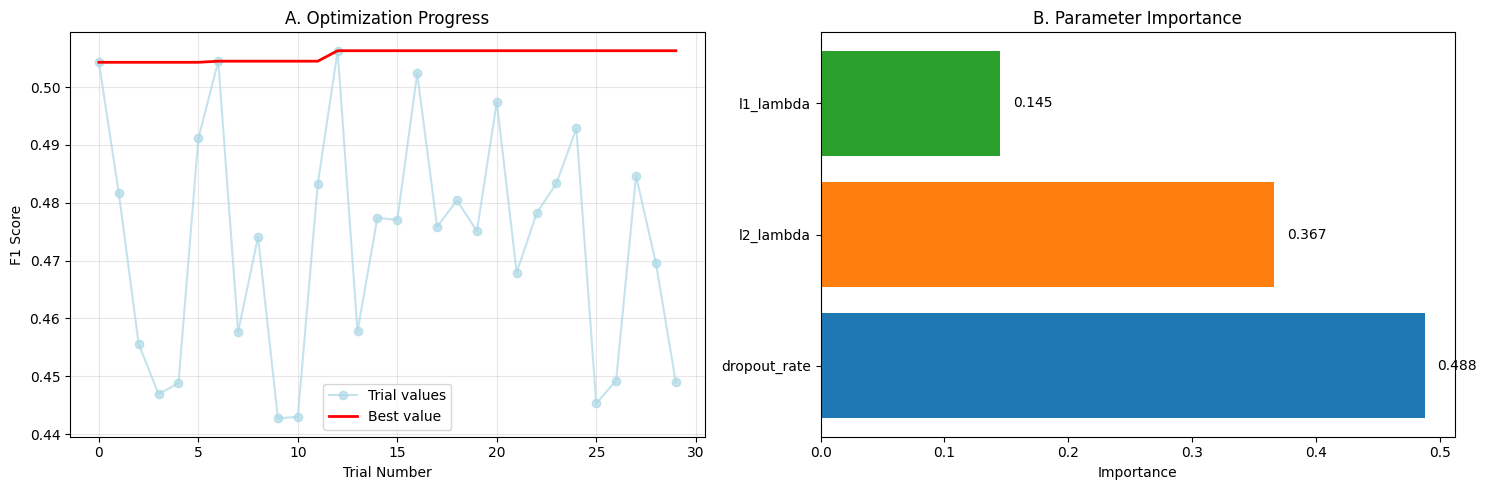

Total trials: 30
Best value: 0.5063
Best parameters: {'dropout_rate': 0.35707685303279774, 'l1_lambda': 0.000365946977770891, 'l2_lambda': 0.0005962578338192308}
Recent improvement rate: -0.004850 per trial
→ Optimization may benefit from more trials

Optimization Statistics:
- Total trials completed: 30
- Failed trials: 0
- Best trial number: 12
- Optimization range: 0.4427 - 0.5063


In [15]:
existing_study = load_optuna_results()
if existing_study is not None:
    study = existing_study
    best_params = study.best_params
    # Figure 1 생성
    fig = create_figure1_visualization(study)
    
    # 수렴성 분석
    convergence_data = analyze_optimization_convergence(study)
    
    # 추가 통계
    print(f"\nOptimization Statistics:")
    print(f"- Total trials completed: {len([t for t in study.trials if t.value is not None])}")
    print(f"- Failed trials: {len([t for t in study.trials if t.value is None])}")
    print(f"- Best trial number: {study.best_trial.number}")
    print(f"- Optimization range: {min([t.value for t in study.trials if t.value is not None]):.4f} - {study.best_value:.4f}")
else:
    print("\n새로운 Optuna 최적화를 시작합니다.")
    print(f"조합: {sel_strategy}_{mod_method}_{resample_method}_{loss_method}")
    study = optuna.create_study(
        direction='maximize', sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3))

    study.optimize(
        lambda trial: objective(trial, mod_method, resample_method, loss_method), 
        n_trials=30, 
        show_progress_bar=True)

    date = datetime.now().strftime('%Y%m%d')
    os.makedirs('../result/optuna_study', exist_ok=True)
    with open(os.path.join('../result/optuna_study', f'optuna_study_{date}.pkl'), 'wb') as f:
        pickle.dump(study, f)

    best_params = study.best_params

### 3단계: 최적 파라미터로 최종 평가 -> final_optimization

In [16]:
import os
import pickle

save_dir = f'../result/final_optimization'

if os.path.exists(os.path.join(save_dir, 'optimization_results.pkl')):
    print("기존 결과를 불러옵니다...")
    with open(os.path.join(save_dir, 'optimization_results.pkl'), 'rb') as f:
        optimization_results = pickle.load(f)
    
    final_results = optimization_results['final_results']
    best_combo = optimization_results['best_combination']
    best_params = optimization_results['best_hyperparams']
    avg_f1 = optimization_results['averages']['f1']
    avg_accuracy = optimization_results['averages']['accuracy']
    avg_roc_auc = optimization_results['averages']['roc_auc']
    avg_pr_auc = optimization_results['averages']['pr_auc']
    
    print(f"\n최종 결과 요약:")
    print(f"평균 F1 점수: {avg_f1:.3f}")
    print(f"평균 Accuracy: {avg_accuracy:.3f}")
    print(f"평균 ROC AUC: {avg_roc_auc:.3f}")
    print(f"평균 PR AUC: {avg_pr_auc:.3f}")
    print(f"사용된 방법: {mod_method}")
    print(f"최적 조합: {best_combo}")

    print(f"\n질병별 상세 성능:")
    for disease, metrics in final_results.items():
        print(f"  {disease}:")
        print(f"    F1: {metrics['f1_score']:.3f} | Acc: {metrics['accuracy']:.3f} | ROC: {metrics['roc_aucs']['Macro']:.3f} | PR: {metrics['pr_aucs']['Macro']:.3f}")
    
    print("하이퍼파라미터 최적화 완료!")
    
else:
    print("새로 학습을 시작합니다...")
    
    final_results = {}
    final_train, final_val, final_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)

    final_train, final_val, final_test, actual_change_dim = apply_to_all_data(final_train, final_val, final_test)

    if mod_method == 'ensemble':
        for disease in mets_cols:
            result = train_sklearn_ensemble(final_train, final_val, final_test, disease)
            final_results[disease] = result
            print(f"  {disease}: F1={result['f1_score']:.3f}, Acc={result['accuracy']:.3f}, ROC={result['roc_aucs']['Macro']:.3f}")
    else:
        batch_size = 16
        dropout_rate = best_params['dropout_rate']    
        if mod_method == 'regularized':
            l1_lambda = best_params['l1_lambda']
            l2_lambda = best_params['l2_lambda']
        else:
            l1_lambda, l2_lambda = 0.0, 0.0
        
        if resample_method == 'none':
            train_loaders, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                final_train, final_val, final_test, batch_size=batch_size)
        else:
            resampled_train = create_resampled_dataset(final_train, resample_method)
            train_loaders = {disease: torch.utils.data.DataLoader(
                torch.utils.data.Subset(resampled_train, 
                    [i for i, item in enumerate(resampled_train) if item['disease_name'] == disease]), 
                batch_size=batch_size, shuffle=True, drop_last=True) for disease in mets_cols}
            
            _, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                final_train, final_val, final_test, batch_size=batch_size)
        
        for disease in mets_cols:
            final_dataset = SingleDietImpactDataset(final_train)
            final_model = create_model_with_dynamic_dims(final_dataset, mets_cols, dropout_rate, l1_lambda, l2_lambda).to(device)     
            result = train_model_with_loss(
                final_model, train_loaders[disease], val_loaders[disease], 
                test_loaders[disease], disease, mod_method, loss_method)
            
            result['evaluation']['method'] = 'deeplearning'
            final_results[disease] = result['evaluation']
            final_results[disease]['model'] = result['model']
            
            metrics = result['evaluation']
            print(f"  {disease}: F1={metrics['f1_score']:.3f}, Acc={metrics['accuracy']:.3f}, ROC={metrics['roc_aucs']['Macro']:.3f}, PR={metrics['pr_aucs']['Macro']:.3f}")

    avg_f1 = np.mean([result['f1_score'] for result in final_results.values()])
    avg_accuracy = np.mean([result['accuracy'] for result in final_results.values()])
    avg_roc_auc = np.mean([result['roc_aucs']['Macro'] for result in final_results.values()])
    avg_pr_auc = np.mean([result['pr_aucs']['Macro'] for result in final_results.values()])

    print(f"\n최종 결과 요약:")
    print(f"평균 F1 점수: {avg_f1:.3f}")
    print(f"평균 Accuracy: {avg_accuracy:.3f}")
    print(f"평균 ROC AUC: {avg_roc_auc:.3f}")
    print(f"평균 PR AUC: {avg_pr_auc:.3f}")
    print(f"사용된 방법: {mod_method}")
    print(f"최적 조합: {best_combo}")

    print(f"\n질병별 상세 성능:")
    for disease, metrics in final_results.items():
        print(f"  {disease}:")
        print(f"    F1: {metrics['f1_score']:.3f} | Acc: {metrics['accuracy']:.3f} | ROC: {metrics['roc_aucs']['Macro']:.3f} | PR: {metrics['pr_aucs']['Macro']:.3f}")

    os.makedirs(save_dir, exist_ok=True)

    detailed_results = []
    for disease, metrics in final_results.items():
        detailed_results.append({
            'Disease': disease,
            'F1_Score': f"{metrics['f1_score']:.3f}",
            'Accuracy': f"{metrics['accuracy']:.3f}",
            'ROC_AUC': f"{metrics['roc_aucs']['Macro']:.3f}",
            'PR_AUC': f"{metrics['pr_aucs']['Macro']:.3f}",
            'Method': metrics.get('method', mod_method)
        })

    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(os.path.join(save_dir, 'detailed_results.csv'), index=False)

    summary_results = {
        'Average_F1': f"{avg_f1:.3f}",
        'Average_Accuracy': f"{avg_accuracy:.3f}",
        'Average_ROC_AUC': f"{avg_roc_auc:.3f}",
        'Average_PR_AUC': f"{avg_pr_auc:.3f}",
        'Best_Combination': str(best_combo),
        'Model_Method': mod_method
    }
    summary_df = pd.DataFrame([summary_results])
    summary_df.to_csv(os.path.join(save_dir, 'summary_results.csv'), index=False)

    optimization_results = {
        'best_combination': best_combo,
        'best_hyperparams': best_params,
        'best_optuna_score': study.best_value,
        'final_results': final_results,
        'averages': {'f1': avg_f1, 'accuracy': avg_accuracy, 'roc_auc': avg_roc_auc, 'pr_auc': avg_pr_auc}
    }

    with open(os.path.join(save_dir, 'optimization_results.pkl'), 'wb') as f:
        pickle.dump(optimization_results, f)

    final_models = {}
    for disease in mets_cols:
        final_models[disease] = final_results[disease].get('model', None)

    torch.save(final_models, os.path.join(save_dir, 'final_best_models.pth'))
    print(f"\n결과 저장: {save_dir}")
    print("하이퍼파라미터 최적화 완료!")

기존 결과를 불러옵니다...

최종 결과 요약:
평균 F1 점수: 0.490
평균 Accuracy: 0.578
평균 ROC AUC: 0.801
평균 PR AUC: 0.502
사용된 방법: base
최적 조합: ('max_disease_change', 'base', 'smote', 'CrossEntropy')

질병별 상세 성능:
  Increased waist circumference:
    F1: 0.479 | Acc: 0.588 | ROC: 0.836 | PR: 0.498
  Elevated blood pressure:
    F1: 0.441 | Acc: 0.506 | ROC: 0.772 | PR: 0.496
  Impaired fasting glucose:
    F1: 0.496 | Acc: 0.522 | ROC: 0.789 | PR: 0.504
  Elevated triglycerides:
    F1: 0.504 | Acc: 0.604 | ROC: 0.783 | PR: 0.496
  Decreased HDL-C:
    F1: 0.533 | Acc: 0.670 | ROC: 0.823 | PR: 0.516
하이퍼파라미터 최적화 완료!


Initial data shape: (29098, 58)
Data shape after max disease change selection: (11238, 65)
Total unique patients: 11238
=== 피처 엔지니어링 시작 ===
✅ PCA 설명 분산비: 0.997
=== 피처 엔지니어링 완료 ===
상호작용 피처: 6개
PCA 피처: 10개
실제 change_dim: 6
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11


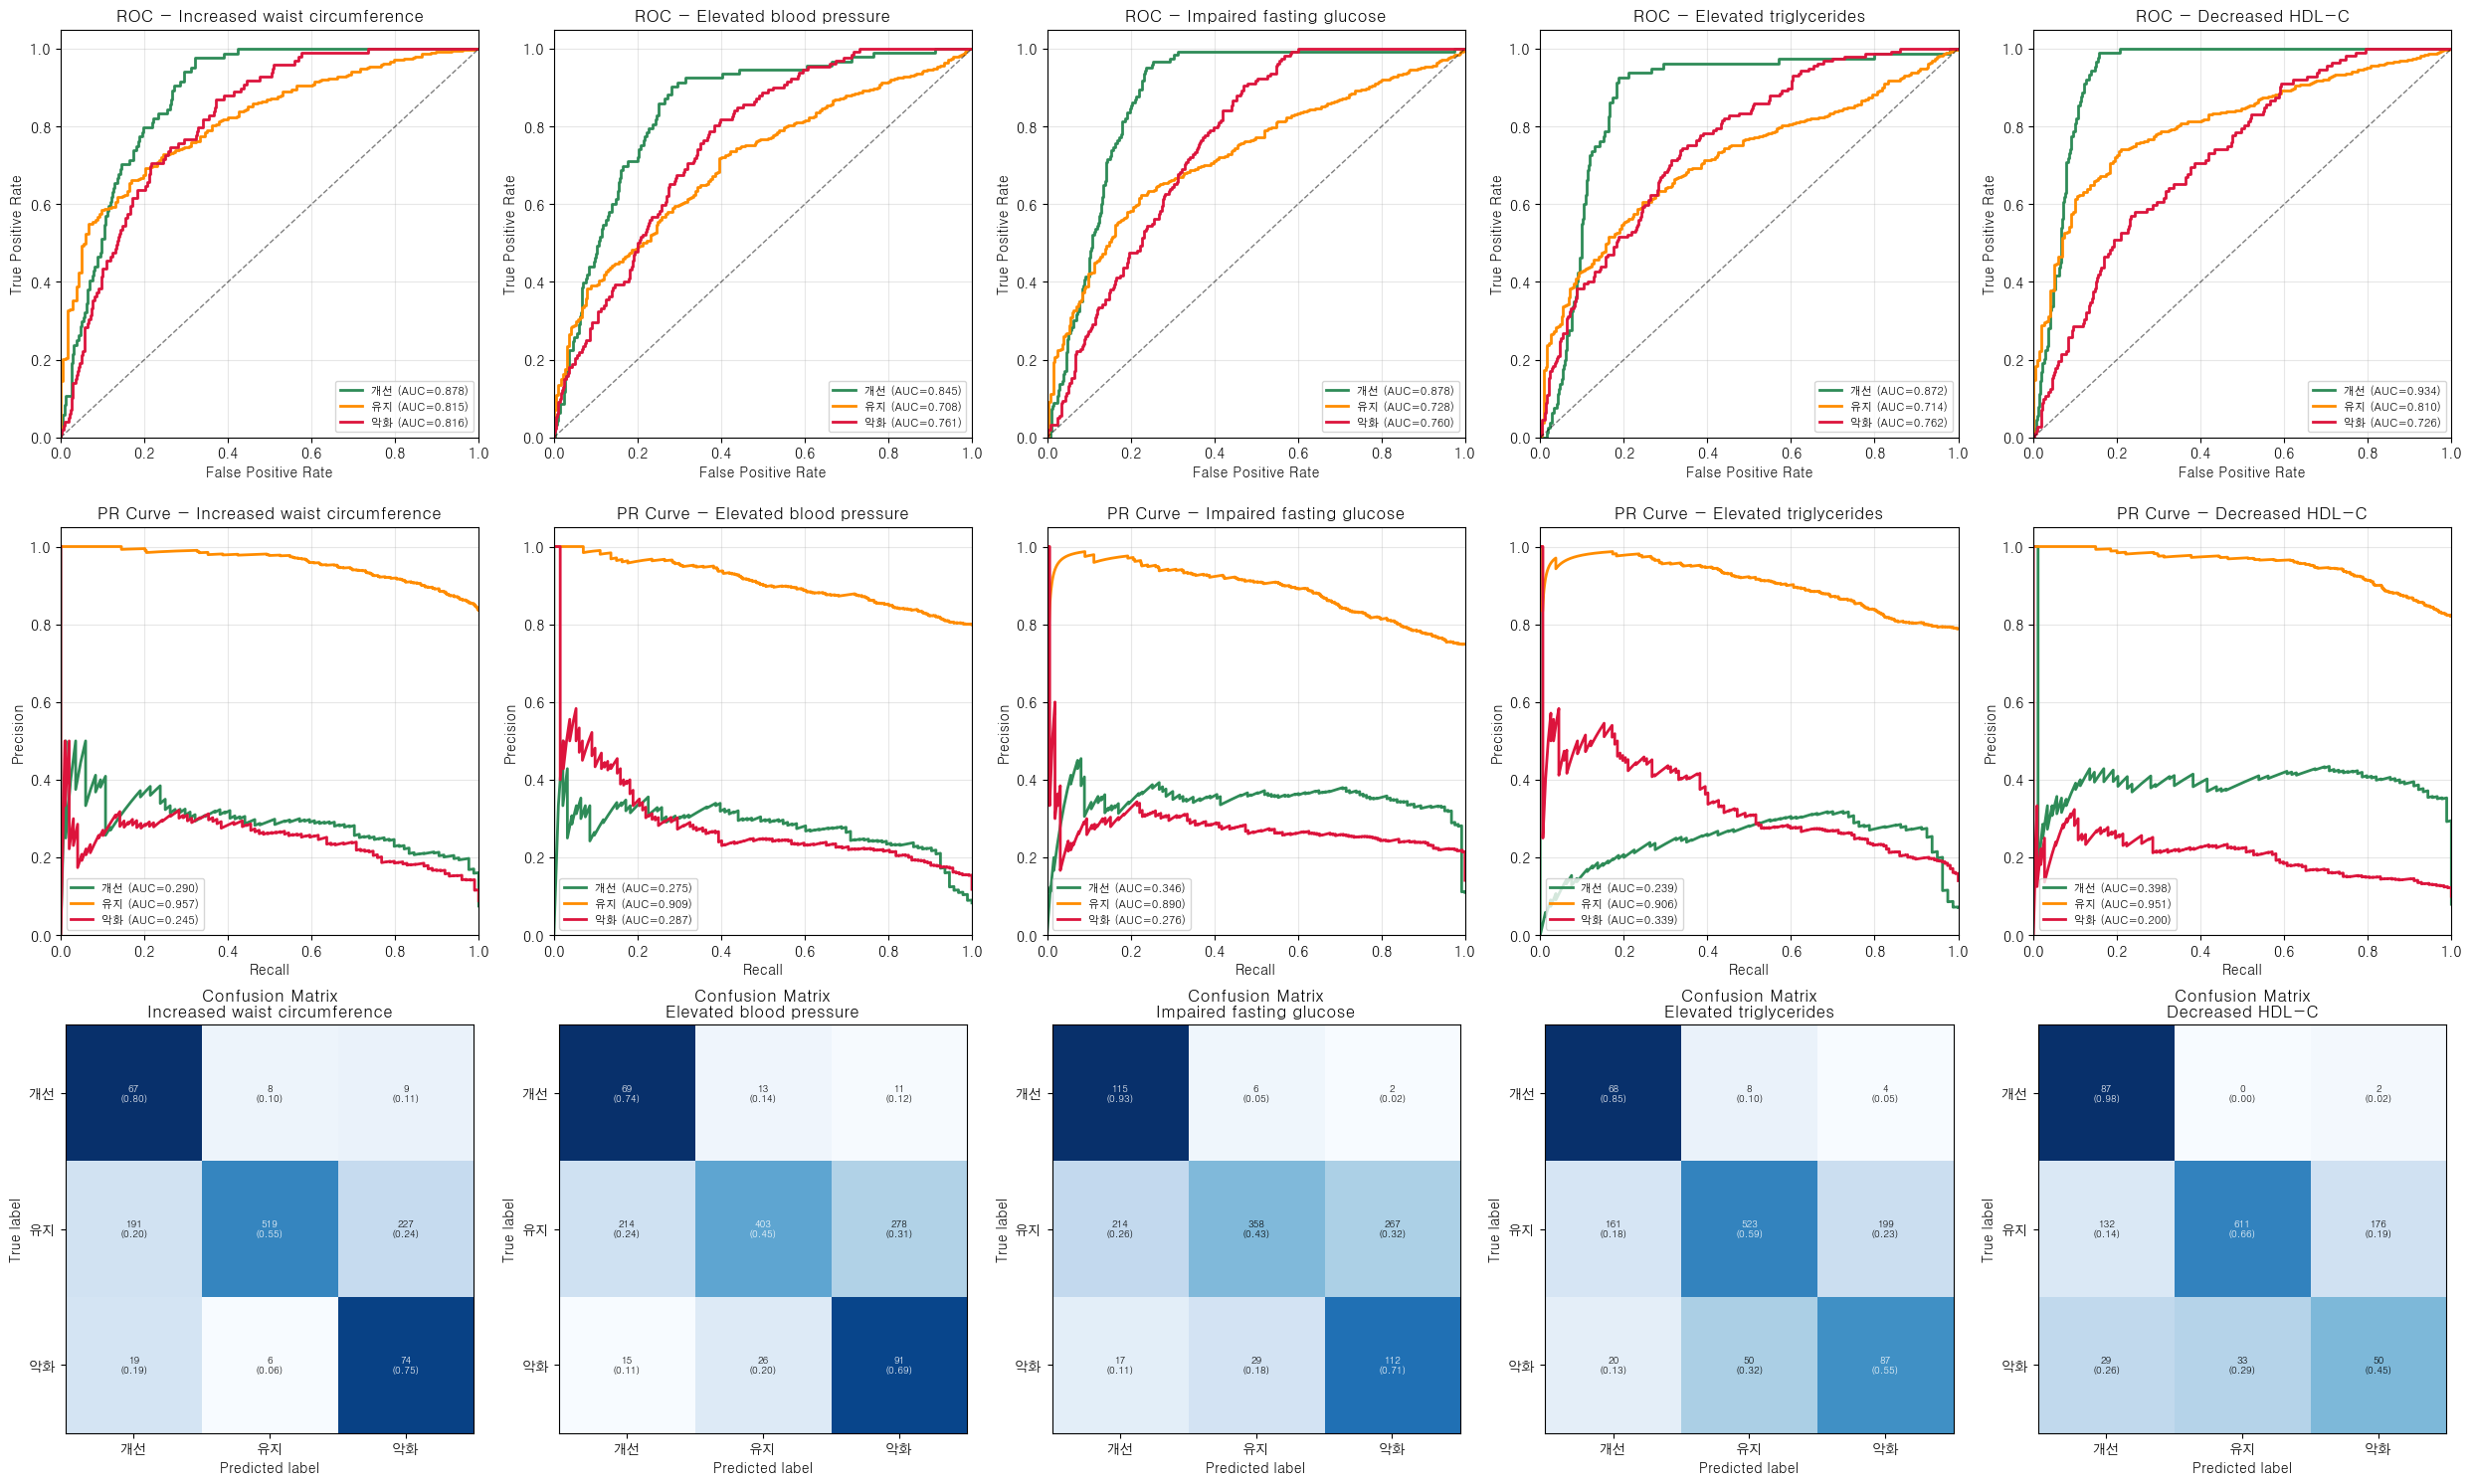

In [21]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = 'C:\\Windows\\Fonts\\H2GTRM.TTF'
font = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font)

final_train, final_val, final_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
final_train, final_val, final_test, actual_change_dim = apply_to_all_data(final_train, final_val, final_test)

if resample_method == 'none':
    _, _, test_loaders = DataLoaderManager.create_disease_loaders(
        final_train, final_val, final_test, batch_size=32)
else:
    _, _, test_loaders = DataLoaderManager.create_disease_loaders(
        final_train, final_val, final_test, batch_size=32)

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
class_names = ['개선', '유지', '악화']
colors = ['#2E8B57', '#FF8C00', '#DC143C']

for col_idx, disease in enumerate(mets_cols):
    if disease in final_results and 'model' in final_results[disease]:
        model = final_results[disease]['model']
        test_loader = test_loaders[disease]
        
        # 예측 결과 수집
        all_pred, all_true, all_prob = [], [], []
        
        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                diet_data = batch['diet'].to(device)
                demo_data = batch['demo'].to(device)
                life_data = batch['life'].to(device)
                bio_data = batch['bio'].to(device)
                change_data = batch['delta'].to(device)
                inter_data = batch['interaction'].to(device)
                pca_data = batch['pca'].to(device)
                target = batch['target'].to(device).squeeze()
                
                outputs = model(diet_data, demo_data, life_data, bio_data, 
                              change_data, inter_data, pca_data, disease)
                pred = torch.argmax(outputs['disease_logits'], dim=1)
                prob = torch.softmax(outputs['disease_logits'], dim=1)
                
                all_pred.extend(pred.cpu().numpy())
                all_true.extend(target.cpu().numpy())
                all_prob.extend(prob.cpu().numpy())
        
        all_true = np.array(all_true)
        all_prob = np.array(all_prob)
        all_pred = np.array(all_pred)
        
        # 1. ROC Curve (첫 번째 행)
        ax_roc = axes[0, col_idx]
        for i in range(3):
            y_true_binary = (all_true == i).astype(int)
            y_prob_class = all_prob[:, i]
            
            if len(np.unique(y_true_binary)) > 1:
                fpr, tpr, _ = roc_curve(y_true_binary, y_prob_class)
                roc_auc = auc(fpr, tpr)
                ax_roc.plot(fpr, tpr, color=colors[i], lw=2, 
                           label=f'{class_names[i]} (AUC={roc_auc:.3f})')
        
        ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC - {disease.replace("_", " ")}')
        ax_roc.legend(loc="lower right", fontsize=8)
        ax_roc.grid(True, alpha=0.3)
        
        # 2. PR Curve (두 번째 행)
        ax_pr = axes[1, col_idx]
        for i in range(3):
            y_true_binary = (all_true == i).astype(int)
            y_prob_class = all_prob[:, i]
            
            if len(np.unique(y_true_binary)) > 1:
                precision, recall, _ = precision_recall_curve(y_true_binary, y_prob_class)
                pr_auc = auc(recall, precision)
                ax_pr.plot(recall, precision, color=colors[i], lw=2,
                          label=f'{class_names[i]} (AUC={pr_auc:.3f})')
        
        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title(f'PR Curve - {disease.replace("_", " ")}')
        ax_pr.legend(loc="lower left", fontsize=8)
        ax_pr.grid(True, alpha=0.3)
        
        # 3. Confusion Matrix (세 번째 행)
        ax_cm = axes[2, col_idx]
        cm = confusion_matrix(all_true, all_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        im = ax_cm.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
        ax_cm.set_title(f'Confusion Matrix\n{disease.replace("_", " ")}')
        
        thresh = cm_normalized.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax_cm.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2f})',
                          ha="center", va="center",
                          color="white" if cm_normalized[i, j] > thresh else "black",
                          fontsize=7)
        
        ax_cm.set_ylabel('True label')
        ax_cm.set_xlabel('Predicted label')
        ax_cm.set_xticks(range(3))
        ax_cm.set_yticks(range(3))
        ax_cm.set_xticklabels(['개선', '유지', '악화'])
        ax_cm.set_yticklabels(['개선', '유지', '악화'])

plt.tight_layout()
os.makedirs('../result/figures', exist_ok=True)
plt.savefig('../result/figures/figure2_roc_pr_confusion.png', dpi=300, bbox_inches='tight')
plt.show()


### 4단계: SHAP 분석 -> shap_analysis

In [8]:
def analyze_feature_categories(category_importance):
    if not category_importance:
        return {}
        
    overall_categories = {}
    for cat_name in ['dietary', 'demographic', 'lifestyle', 'biomarker', 'temporal', 'engineered']:
        scores = [category_importance[disease][cat_name] for disease in category_importance.keys() 
                 if cat_name in category_importance[disease]]
        if scores:
            overall_categories[cat_name] = np.mean(scores)
        else:
            overall_categories[cat_name] = 0.0
    
    total_importance = sum(overall_categories.values())
    if total_importance == 0:
        return {}
        
    category_percentages = {cat: (score/total_importance)*100 for cat, score in overall_categories.items()}
    
    print("전체 평균 기여도:")
    for cat, percentage in sorted(category_percentages.items(), key=lambda x: x[1], reverse=True):
        cat_names = {'dietary': '식습관', 'biomarker': '생체지표', 'temporal': '시간적변화', 
                    'demographic': '인구통계', 'lifestyle': '생활습관', 'engineered': '엔지니어링'}
        print(f"  {cat_names.get(cat, cat)}: {percentage:.1f}%")
    
    return category_percentages

def save_results(results, category_importance, feature_names):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    save_dir = f'../result/shap_analysis/{timestamp}'
    os.makedirs(save_dir, exist_ok=True)
    
    with open(os.path.join(save_dir, 'shap_results.pkl'), 'wb') as f:
        pickle.dump({'results': results, 'category_importance': category_importance, 
                    'feature_names': feature_names}, f)
    
    importance_data = []
    for disease, result in results.items():
        for i, importance in enumerate(result['overall_importance']):
            if i < len(result['feature_names']):
                importance_data.append({
                    'Disease': disease,
                    'Feature': result['feature_names'][i],
                    'Importance': importance,
                    'Category': get_feature_category(i)
                })
    
    importance_df = pd.DataFrame(importance_data)
    importance_df.to_csv(os.path.join(save_dir, 'feature_importance.csv'), index=False)
    
    category_df = pd.DataFrame(category_importance).T
    category_df.to_csv(os.path.join(save_dir, 'category_importance.csv'))
    
    print(f"\n결과 저장됨: {save_dir}")
    return save_dir

def get_feature_category(index):
    if index < 19: return 'dietary'
    elif index < 23: return 'demographic'  
    elif index < 26: return 'lifestyle'
    elif index < 37: return 'biomarker'
    elif index < 59: return 'temporal'
    else: return 'engineered'

In [9]:
# 4단계 SHAP 분석 수정 버전
import shap
from SHAP import load_existing_shap_results, load_trained_model_and_data, extract_features_and_targets, create_model_wrapper

results, category_importance, feature_names = load_existing_shap_results()

if results is None:
    print("기존 SHAP 결과 없음. 새로 분석을 수행합니다.")
    
    # actual_change_dim을 먼저 얻기 위해 데이터 처리
    temp_train, temp_val, temp_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
    temp_train, temp_val, temp_test, actual_change_dim = apply_to_all_data(temp_train, temp_val, temp_test)
    
    # 데이터셋 객체 생성
    temp_dataset = SingleDietImpactDataset(temp_train)
    
    # 이제 dataset 객체를 전달
    model, train_df, _, _, _, _, test_loaders, mets_cols = load_trained_model_and_data(best_combo, best_params, temp_dataset)

    feature_names = train_df.columns.tolist()
    feature_categories = {
        'dietary': list(range(19)),
        'demographic': list(range(19, 23)),
        'lifestyle': list(range(23, 26)),
        'biomarker': list(range(26, 37)),
        'temporal': list(range(37, 37+actual_change_dim)),
        'engineered': list(range(37+actual_change_dim, len(feature_names)-5))
    }
    
    results = {}
    category_importance = {}
    
    for disease_name in mets_cols:
        X_test, y_test = extract_features_and_targets(test_loaders[disease_name], disease_name)
        
        n_samples = min(100, len(X_test))
        indices = np.random.choice(len(X_test), n_samples, replace=False)
        X_sample = X_test[indices]
        
        n_background = min(50, len(X_sample))
        X_background = X_sample[:n_background]
        
        n_explain = min(20, len(X_sample))
        X_explain = X_sample[:n_explain]
        
        # dataset 객체를 전달
        model_wrapper = create_model_wrapper(model, disease_name, temp_dataset)
        
        explainer = shap.Explainer(model_wrapper, X_background)
        shap_values = explainer(X_explain)
        
        importance_improve = np.mean(np.abs(shap_values.values[:, :, 0]), axis=0)
        importance_maintain = np.mean(np.abs(shap_values.values[:, :, 1]), axis=0)  
        importance_worsen = np.mean(np.abs(shap_values.values[:, :, 2]), axis=0)
        
        overall_importance = (importance_improve + importance_maintain + importance_worsen) / 3
        
        results[disease_name] = {
            'shap_values': shap_values,
            'importance_improve': importance_improve,
            'importance_maintain': importance_maintain, 
            'importance_worsen': importance_worsen,
            'overall_importance': overall_importance,
            'feature_names': feature_names[:len(overall_importance)]
        }
        
        cat_importance = {}
        for cat_name, indices in feature_categories.items():
            valid_indices = [i for i in indices if i < len(overall_importance)]
            if valid_indices:
                cat_importance[cat_name] = np.mean([overall_importance[i] for i in valid_indices])
            else:
                cat_importance[cat_name] = 0.0
        
        category_importance[disease_name] = cat_importance
        print(f"  {disease_name}: SHAP 분석 완료")
else:
    print("기존 SHAP 결과를 사용합니다.")

category_percentages = analyze_feature_categories(category_importance)
if category_importance:
    print("\n=== 주요 발견사항 ===")
    print(f"식습관 요인 기여도: {category_percentages.get('dietary', 0):.1f}%")
    print(f"생체지표 기여도: {category_percentages.get('biomarker', 0):.1f}%") 
    print(f"시간적변화 기여도: {category_percentages.get('temporal', 0):.1f}%")
    print(f"인구통계 기여도: {category_percentages.get('demographic', 0):.1f}%")
    print(f"생활습관 기여도: {category_percentages.get('lifestyle', 0):.1f}%")
    print(f"엔지니어링 기여도: {category_percentages.get('engineered', 0):.1f}%")

if 'feature_categories' in locals():
    save_dir = save_results(results, category_importance, feature_names)
    print(f"새로운 결과 저장됨: {save_dir}")

기존 SHAP 결과 발견: ../result/shap_analysis\20250903_0211\shap_results.pkl
기존 SHAP 결과를 성공적으로 로드했습니다.
기존 SHAP 결과를 사용합니다.
전체 평균 기여도:
  엔지니어링: 41.0%
  인구통계: 22.1%
  생체지표: 11.7%
  생활습관: 11.3%
  식습관: 7.0%
  시간적변화: 6.9%

=== 주요 발견사항 ===
식습관 요인 기여도: 7.0%
생체지표 기여도: 11.7%
시간적변화 기여도: 6.9%
인구통계 기여도: 22.1%
생활습관 기여도: 11.3%
엔지니어링 기여도: 41.0%


### 5단계: 추천 모델

In [10]:
from diet_recommend import DietaryRecommendationSystem

In [11]:
final_test = test_df_global.copy()

# 모델 로딩 부분 수정
try:
    best_disease = max(final_results.keys(), key=lambda k: final_results[k]['f1_score'])
    print(f"선택된 질병: {best_disease} (F1: {final_results[best_disease]['f1_score']:.3f})")
    
    model_path = os.path.join('../result/final_optimization', 'final_best_models.pth')
    if os.path.exists(model_path):
        saved_models = torch.load(model_path, map_location=device)
        trained_model = saved_models[best_disease]
        
        recommender = DietaryRecommendationSystem(trained_model=trained_model, device=device)
        print("추천 시스템 준비 완료")
    else:
        print("저장된 모델을 찾을 수 없습니다.")
        recommender = None
        
except Exception as e:
    print(f"모델 로딩 중 오류: {e}")
    recommender = None


선택된 질병: Decreased HDL-C (F1: 0.533)
추천 시스템 초기화 완료 - 총 피처 차원: 75
추천 시스템 준비 완료


In [12]:
sample_index = 0
sample_patient = final_test.iloc[sample_index]

# disease delta 컬럼들 정의
disease_delta_cols = [f'{disease}_delta' for disease in mets_cols]

# delta 컬럼 제외하고 피처 추출
patient_features = sample_patient.drop([col for col in sample_patient.index if col in disease_delta_cols]).values

print(f"\n=== {sample_index+1}번째 환자 추천 ===")
print(f"환자 피처 차원: {len(patient_features)}")

targets = {best_disease: 'improve'}

recommendations = recommender.generate_recommendations(
    patient_features=patient_features,
    targets=targets,
    max_change=1.5,
    method='optimization'
)

# 결과 출력
if 'error' in recommendations:
    print(f"오류: {recommendations['error']}")
else:
    print(f"총 {recommendations['total_changes']}개 식습관 변경 권장")
    print(f"실행 가능성: {recommendations['feasibility_score']:.1%}")
    
    if recommendations['recommendations']:
        print("\n식습관 권장사항:")
        for food, rec in recommendations['recommendations'].items():
            print(f"  • {rec['recommendation']}")
    
    print(f"\n예상 효과:")
    for disease, effect in recommendations['predicted_effects'].items():
        current = effect['current_improve_prob']
        predicted = effect['predicted_improve_prob']
        change = effect['improvement_change']
        print(f"  {disease}: {current:.1%} → {predicted:.1%} ({change:+.1%})")


=== 1번째 환자 추천 ===
환자 피처 차원: 75
오류: 최적화 실패


In [13]:
def evaluate_recommendation_system(recommender, rec_method, test_data, targets, n_patients=50):
    if recommender is None:
        print("추천 시스템이 준비되지 않았습니다.")
        return {}
        
    print(f"=== 추천 시스템 평가 ({n_patients}명 대상) ===")
    
    results = {
        'improvement_predictions': [],
        'feasibility_scores': [],
        'recommendation_counts': [],
        'consistency_scores': [],
        'diversity_scores': []
    }
    
    # disease delta 컬럼들 정의
    disease_delta_cols = [f'{disease}_delta' for disease in mets_cols]
    
    try:
        # 1. 개선 효과 시뮬레이션
        print("1. 개선 효과 시뮬레이션...")
        improvement_count = 0
        
        for i in range(min(n_patients, len(test_data))):
            patient_data = test_data.iloc[i]
            features = patient_data.drop([col for col in patient_data.index 
                                        if col in disease_delta_cols]).values
            
            rec = recommender.generate_recommendations(
                patient_features=features,
                targets=targets,
                max_change=1.0,
                method=rec_method
            )
            
            if 'error' not in rec:
                for disease, effect in rec['predicted_effects'].items():
                    improvement_change = effect['improvement_change']
                    results['improvement_predictions'].append(improvement_change)
                    if improvement_change > 0.05:
                        improvement_count += 1
                
                results['feasibility_scores'].append(rec['feasibility_score'])
                results['recommendation_counts'].append(rec['total_changes'])
        
        # 결과 요약
        if results['improvement_predictions']:
            avg_improvement = np.mean(results['improvement_predictions'])
            improvement_rate = improvement_count / len(results['improvement_predictions'])
            print(f"평균 개선 예상 효과: {avg_improvement:.1%}")
            print(f"개선 예상 비율: {improvement_rate:.1%}")
        
        if results['feasibility_scores']:
            avg_feasibility = np.mean(results['feasibility_scores'])
            print(f"평균 실행 가능성: {avg_feasibility:.1%}")
        
        if results['recommendation_counts']:
            avg_changes = np.mean(results['recommendation_counts'])
            print(f"평균 추천 식품 수: {avg_changes:.1f}개")
            
    except Exception as e:
        print(f"평가 중 오류: {e}")
    
    return results

In [14]:
targets = {best_disease: 'improve'}
evaluation_results = evaluate_recommendation_system(
    recommender, 'optimization', final_test, targets, n_patients=20
)


=== 추천 시스템 평가 (20명 대상) ===
1. 개선 효과 시뮬레이션...
